In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear

In [13]:
# Loading each Raman spectrum from its sheet
log_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx", sheet_name='ec_log_mean raman')
sta_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx", sheet_name='ec_sta_mean raman')
ref_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx", sheet_name="tbl_15components")

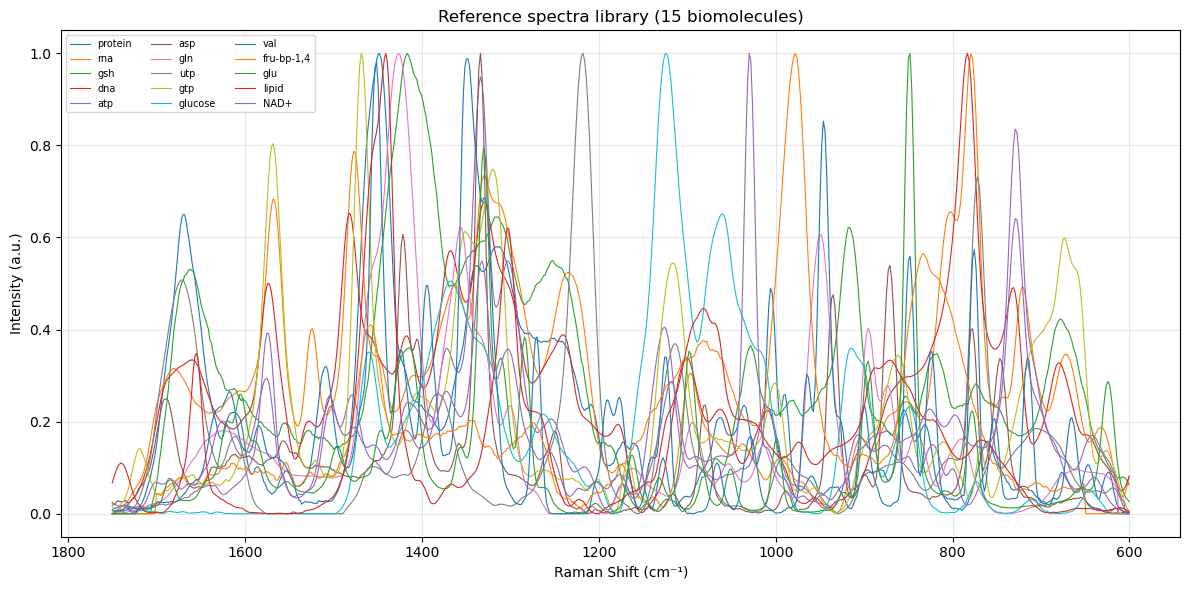

In [14]:
# Extracting wavenumber axis and biomolecule names from reference spectra (tbl_15components)
wn = ref_df["wavenumber"].values
ref_names = [col for col in ref_df.columns if col != "wavenumber"]

# Plotting all 15 reference spectra together for visual comparison
plt.figure(figsize=(12, 6))
for name in ref_names:
    plt.plot(wn, ref_df[name], linewidth=0.8, label=name)

plt.gca().invert_xaxis()
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.title("Reference spectra library (15 biomolecules)")
plt.legend(fontsize=7, ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

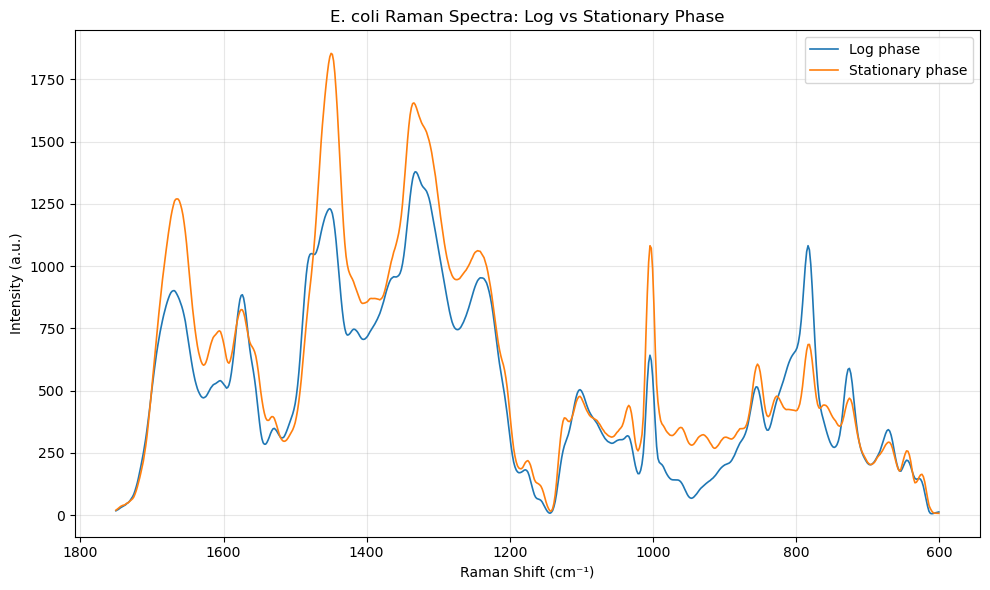

In [15]:
# Standardise column names
log_df.columns = ["wavenumber", "intensity"]
sta_df.columns = ["wavenumber", "intensity"]

# Sort ascending wavenumber
log_df = log_df.sort_values("wavenumber").reset_index(drop=True)
sta_df = sta_df.sort_values("wavenumber").reset_index(drop=True)

# Ensure reference spectra match ascending wavenumber order
if ref_df.iloc[0, 0] > ref_df.iloc[-1, 0]:
    ref_df = ref_df.iloc[::-1].reset_index(drop=True)

# Reference spectra matrix (637 data points x 15 features (biomolecules))
R = ref_df.iloc[:, 1:].values

# Plot raw spectra
plt.figure(figsize=(10, 6))
plt.plot(log_df["wavenumber"], log_df["intensity"], label="Log phase", linewidth=1.2)
plt.plot(sta_df["wavenumber"], sta_df["intensity"], label="Stationary phase", linewidth=1.2)
plt.gca().invert_xaxis()
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.title("E. coli Raman Spectra: Log vs Stationary Phase")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Nyquist criterion for Raman
dnu = np.mean(np.diff(x))  # wavenumber spacing
Delta_nu = x.max() - x.min()  # total wavenumber range

# Fourier conjugate spacing
Delta_t = 1.0 / dnu  # range in Fourier space (from sampling theorem)

N_ind = (2.0 / np.pi) * Delta_nu * Delta_t

print(f"Wavenumber spacing dν = {dnu:.4f} cm⁻¹")
print(f"Wavenumber range Δν = {Delta_nu:.2f} cm⁻¹")
print(f"Fourier range Δt = 1/dν = {Delta_t:.4f} cm")
print(f"N_ind = (2/π) × Δν × Δt = {N_ind:.1f}")
print(f"N_data = {len(x)}")

Wavenumber spacing dν = 1.8085 cm⁻¹
Wavenumber range Δν = 1150.21 cm⁻¹
Fourier range Δt = 1/dν = 0.5529 cm
N_ind = (2/π) × Δν × Δt = 404.9
N_data = 637


## Normalisation

In [17]:
# Normalise intensities so max = 1, matching reference spectra which has been normalised already
log_df["intensity_norm"] = log_df["intensity"] / log_df["intensity"].max()
sta_df["intensity_norm"] = sta_df["intensity"] / sta_df["intensity"].max()

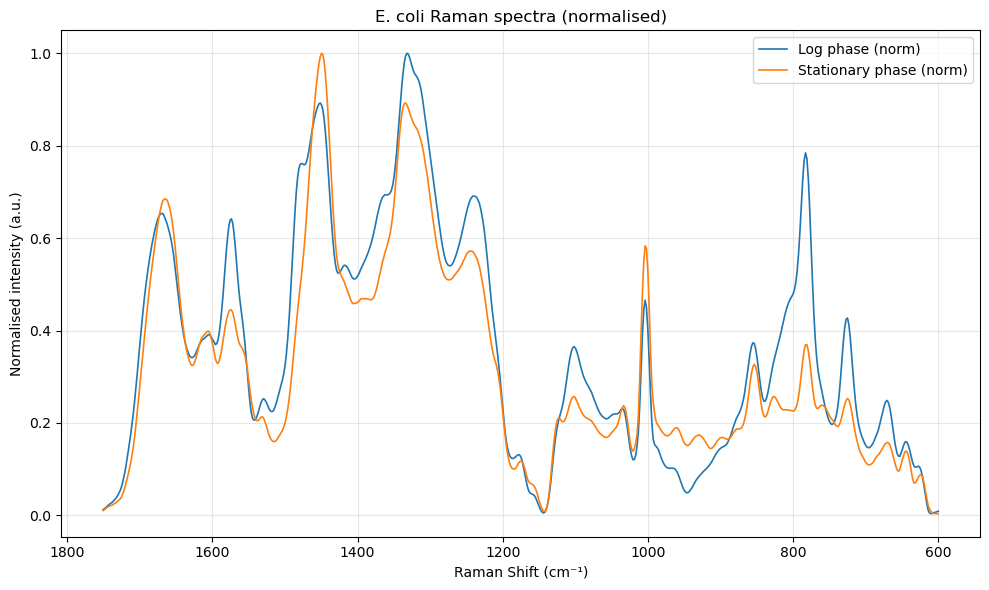

In [18]:
# Plotting with normalised data

plt.figure(figsize=(10, 6))
plt.plot(log_df["wavenumber"], log_df["intensity_norm"], label="Log phase (norm)", linewidth=1.2)
plt.plot(sta_df["wavenumber"], sta_df["intensity_norm"], label="Stationary phase (norm)", linewidth=1.2)

plt.gca().invert_xaxis()
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Normalised intensity (a.u.)")
plt.title("E. coli Raman spectra (normalised)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# The peaks are noticeably more defined now, especially for the log phase data.

In [19]:
# Wavenumber axis and log-phase data for fitting
x = log_df["wavenumber"].values
y = log_df["intensity_norm"].values

# Fitting and BFI

## Log Spectra Fitting

LOG PHASE: BFI forward selection
Data points: 637, Baseline degree: 2
Priors: baseline Δb = 1.0, biomolecule ΔA = 1.0

step  biomolecule      k  rank  cond(X)        RSS         s²        lnBFI       ΔlnBFI
------------------------------------------------------------------------------------------
   0      (baseline)   3     3   3.76e+00   3.070e+01  4.842e-02     52.2913         -
   1             gsh   4     4   6.52e+00   7.866e+00  1.243e-02    481.1738   428.8825
   2             rna   5     5   7.57e+00   5.577e+00  8.824e-03    586.9980   105.8242
   3             glu   6     6   7.76e+00   4.704e+00  7.456e-03    637.8156    50.8175
   4         protein   7     7   2.03e+01   3.612e+00  5.733e-03    718.8047    80.9892
   5             dna   8     8   2.06e+01   3.310e+00  5.262e-03    743.3176    24.5129
   6             gln   9     9   2.07e+01   2.907e+00  4.629e-03    781.0338    37.7162
   7             utp  10    10   2.17e+01   2.759e+00  4.400e-03    794.3168    13.2829

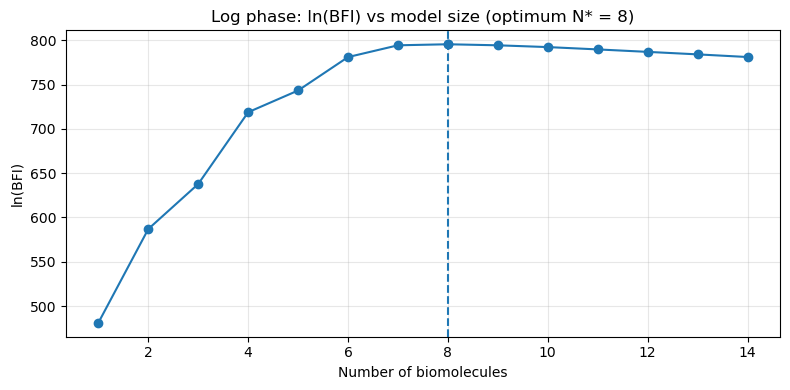

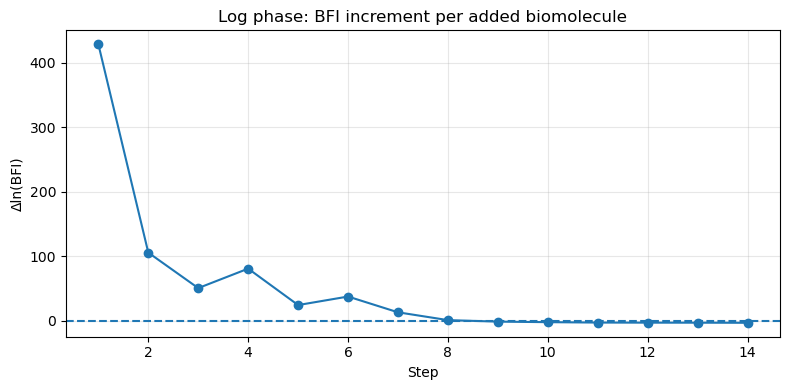

In [25]:
# ===========================
# SETTINGS
# ===========================
bmax         = 0.5              # prior half-width for baseline coefficients (±bmax)
Amax         = 1.0              # prior width for biomolecule coefficients (0 to Amax)

baseline_deg = 2                # degree-2 polynomial baseline (constant + linear + quadratic)
n_base = baseline_deg + 1       # 3 baseline parameters (b₀, b₁, b₂)

n      = len(x)                 # number of data points (637)

# ===========================
# FUNCTIONS
# ===========================

def scale_wn(x):
    """Scale wavenumbers to [-1, 1] for numerical stability of polynomial baseline."""
    return 2 * (x - x.min()) / (x.max() - x.min()) - 1.0

def build_design_matrix(x, ref_matrix, selected_idx, deg):
    """
    Build design matrix: [baseline columns | selected reference spectra].
    Baseline is a quadratic polynomial (degree 2) in scaled wavenumber.
    Each selected reference spectrum becomes one column.
    """
    xs = scale_wn(x)
    baseline = np.vstack([xs**i for i in range(deg + 1)]).T
    if len(selected_idx) > 0:
        spectra = ref_matrix[:, selected_idx]
    else:
        spectra = np.zeros((len(x), 0))
    return np.hstack([baseline, spectra])

def fit_model(X, y, n_base):
    """
    Non-negative bounded least squares.
    Baseline coefficients are unconstrained; biomolecule coefficients >= 0
    (negative concentrations are unphysical).
    Returns fitted parameters, predictions, residual statistics, and covariance matrix.
    """
    k = X.shape[1]
    lb = np.full(k, -np.inf)
    ub = np.full(k,  np.inf)
    lb[n_base:] = 0.0  # enforce non-negativity on biomolecule coefficients

    res = lsq_linear(X, y, bounds=(lb, ub), lsmr_tol='auto', verbose=0)
    beta = res.x
    yhat = X @ beta
    RSS  = float(np.sum((y - yhat)**2))       # residual sum of squares
    dof  = max(n - k, 1)                       # degrees of freedom
    s2   = RSS / dof                           # noise variance estimate (plug-in for σ²)

    # Parameter covariance matrix: Cov = s² × (XᵀX)⁻¹
    XtX = X.T @ X
    try:
        XtX_inv = np.linalg.inv(XtX)
    except np.linalg.LinAlgError:
        XtX_inv = np.linalg.pinv(XtX)

    cov  = s2 * XtX_inv
    cond = float(np.linalg.cond(X))            # condition number (check for ill-conditioning)
    rank = np.linalg.matrix_rank(X)
    return beta, yhat, RSS, s2, cov, rank, cond

def ln_bfi(s2, cov, prior_widths, n, k):
    """
    Log Bayes Factor Integral (Mayerl, Sapelkin et al. 2024, Eq. 6):
        ln(BFI) = ln(L_max) + (k/2)ln(2π) + (1/2)ln(det(Cov)) - Σln(Δpᵢ)

    Noise variance σ² is unknown, so we use the plug-in estimator s² = RSS/(n-k).
    The Occam factor naturally penalises models with too many or correlated parameters.
    """
    dof = n - k
    if dof <= 0 or s2 <= 0 or not np.isfinite(s2):
        return np.nan

    sign, logdet = np.linalg.slogdet(cov)
    if sign != 1 or not np.isfinite(logdet):
        return np.nan

    # Term 1: Log-likelihood at best fit (with σ² replaced by s² in BFI formula)
    ln_likelihood = -0.5 * n * np.log(2*np.pi) - 0.5 * n * np.log(s2) - 0.5 * dof

    # Term 2: Occam factor - rewards tight parameter constraints, penalises correlations
    ln_occam = 0.5 * k * np.log(2*np.pi) + 0.5 * logdet

    # Term 3: Prior normalisation - wider priors penalise the model more
    ln_prior = -np.sum(np.log(prior_widths))

    return float(ln_likelihood + ln_occam + ln_prior)

# ===========================
# FORWARD SELECTION METHOD: Start with baseline only, add one biomolecule per step, (whichever maximises ln(BFI)), stop when no addition improves the score.
# ===========================

# Start with baseline-only model (no biomolecules)
selected = []
history  = []

X0 = build_design_matrix(x, R, [], baseline_deg)
beta0, yhat0, RSS0, s20, cov0, rank0, cond0 = fit_model(X0, y, n_base)
prior0     = np.array([2*bmax] * n_base)       # baseline prior widths
lnBFI_0    = ln_bfi(s20, cov0, prior0, n=n, k=X0.shape[1])
prev_lnBFI = lnBFI_0

print("LOG PHASE: BFI forward selection")
print(f"Data points: {n}, Baseline degree: {baseline_deg}")
print(f"Priors: baseline Δb = {2*bmax}, biomolecule ΔA = {Amax}")
print()
print("step  biomolecule      k  rank  cond(X)        RSS         s²        lnBFI       ΔlnBFI")
print("-" * 90)
print(f"   0  {'(baseline)':>14s}  {X0.shape[1]:>2d}  {rank0:>4d}  {cond0:>9.2e}  {RSS0:>10.3e}  {s20:>9.3e}  {lnBFI_0:>10.4f}         -")

# At each step, try every remaining biomolecule
# and add whichever gives the largest increase in ln(BFI)
for step in range(1, R.shape[1] + 1):
    best = None

    for idx in range(R.shape[1]):
        if idx in selected:
            continue

        # Trial model: current selection + this candidate
        trial = selected + [idx]
        X = build_design_matrix(x, R, trial, baseline_deg)
        beta, yhat, RSS, s2, cov, rank, cond = fit_model(X, y, n_base)

        # Prior widths: baseline gets Δb = 2×bmax, each biomolecule gets ΔA = Amax
        prior = np.array([2*bmax]*n_base + [Amax]*len(trial))
        lnBFI = ln_bfi(s2, cov, prior, n=n, k=X.shape[1])

        if not np.isfinite(lnBFI):
            continue

        # Keep track of the best candidate this step
        delta = lnBFI - prev_lnBFI
        if best is None or delta > best[0]:
            best = (delta, lnBFI, idx, X.shape[1], rank, cond, RSS, s2, yhat, beta)

    if best is None:
        break

    # Lock in the best candidate and record results
    delta, lnBFI, idx, k, rank, cond, RSS, s2, yhat, beta = best
    selected.append(idx)
    history.append((step, idx, ref_names[idx], lnBFI, delta, k, rank, cond, RSS, s2, yhat, beta))
    print(f"{step:>4d}  {ref_names[idx]:>14s}  {k:>2d}  {rank:>4d}  {cond:>9.2e}  {RSS:>10.3e}  {s2:>9.3e}  {lnBFI:>10.4f}  {delta:>9.4f}")
    prev_lnBFI = lnBFI

# ===========================
# FIND OPTIMUM MODEL + SELECTED BIOMOLECULES
# ===========================
# N* = number of biomolecules at maximum ln(BFI)
steps_arr = np.array([h[0] for h in history])
lnBFI_arr = np.array([h[3] for h in history])
delta_arr = np.array([h[4] for h in history])

best_idx = int(np.nanargmax(lnBFI_arr))
N_star   = int(steps_arr[best_idx])
ln_star  = float(lnBFI_arr[best_idx])

selected_names = [history[i][2] for i in range(N_star)]
print(f"\nOptimal model: N* = {N_star} biomolecules, lnBFI = {ln_star:.4f}")
print("Selected:", selected_names)

# ===========================
# PLOTS
# ===========================

# ln(BFI) vs model size - peak indicates optimal complexity
plt.figure(figsize=(8, 4))
plt.plot(steps_arr, lnBFI_arr, marker="o")
plt.axvline(N_star, linestyle="--")
plt.scatter([N_star], [ln_star], zorder=5)
plt.xlabel("Number of biomolecules")
plt.ylabel("ln(BFI)")
plt.title(f"Log phase: ln(BFI) vs model size (optimum N* = {N_star})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Incremental gain - shows diminishing returns and where BFI starts declining
plt.figure(figsize=(8, 4))
plt.plot(steps_arr, delta_arr, marker="o")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Step")
plt.ylabel("Δln(BFI)")
plt.title("Log phase: BFI increment per added biomolecule")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

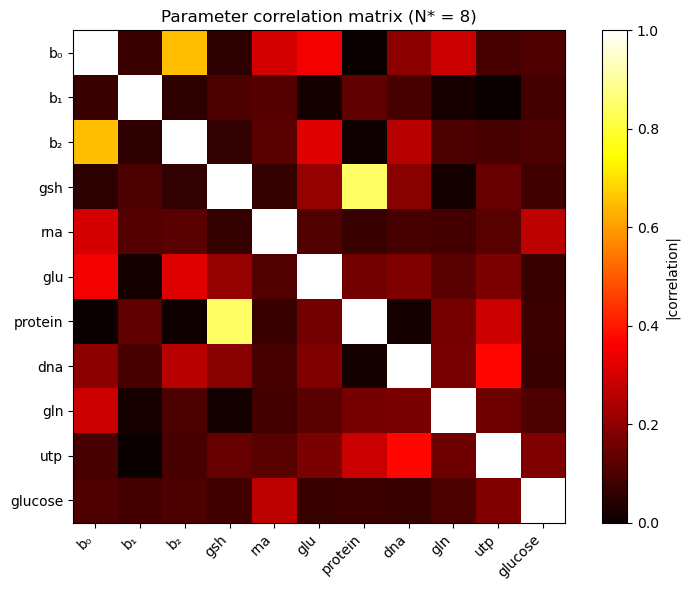

In [26]:
# Correlation matrix at optimal model N*
# Shows how strongly each parameter's estimate depends on others
# High correlation between two parameters suggests they are hard to distinguish

# Recalculate covariance at optimal model
X_star = build_design_matrix(x, R, selected[:N_star], baseline_deg)
_, _, _, s2_star, cov_star, _, _ = fit_model(X_star, y, n_base)

# Convert covariance to correlation (normalise to [-1, 1])
diag = np.sqrt(np.diag(cov_star))
corr_matrix = cov_star / np.outer(diag, diag)

# Parameter labels for axes
param_labels = ["b₀", "b₁", "b₂"] + selected_names

plt.figure(figsize=(8, 6))
plt.imshow(np.abs(corr_matrix), cmap='hot', vmin=0, vmax=1)
plt.colorbar(label="|correlation|")
plt.xticks(range(len(param_labels)), param_labels, rotation=45, ha='right')
plt.yticks(range(len(param_labels)), param_labels)
plt.title(f"Parameter correlation matrix (N* = {N_star})")
plt.tight_layout()
plt.show()

In [27]:
# ===========================
# LOG PHASE: RESULTS SUMMARY
# ===========================
best_entry = history[best_idx]
k_best   = best_entry[5]
RSS_best = best_entry[8]
s2_best  = best_entry[9]

print("=" * 70)
print("LOG PHASE RESULTS SUMMARY")
print("=" * 70)
print(f"Optimal number of biomolecules: N* = {N_star}")
print(f"Maximum ln(BFI): {ln_star:.2f}")
print(f"Data points: n = {n}")
print(f"Total parameters: k = {k_best} (3 baseline + {N_star} biomolecules)")
print(f"RSS: {RSS_best:.4f}")
print(f"Noise estimate: s² = {s2_best:.6f}")

print(f"\nSelected biomolecules (in order of selection):")
for i in range(N_star):
    print(f"  {i+1}. {history[i][2]}")

LOG PHASE RESULTS SUMMARY
Optimal number of biomolecules: N* = 8
Maximum ln(BFI): 795.49
Data points: n = 637
Total parameters: k = 11 (3 baseline + 8 biomolecules)
RSS: 2.7199
Noise estimate: s² = 0.004345

Selected biomolecules (in order of selection):
  1. gsh
  2. rna
  3. glu
  4. protein
  5. dna
  6. gln
  7. utp
  8. glucose


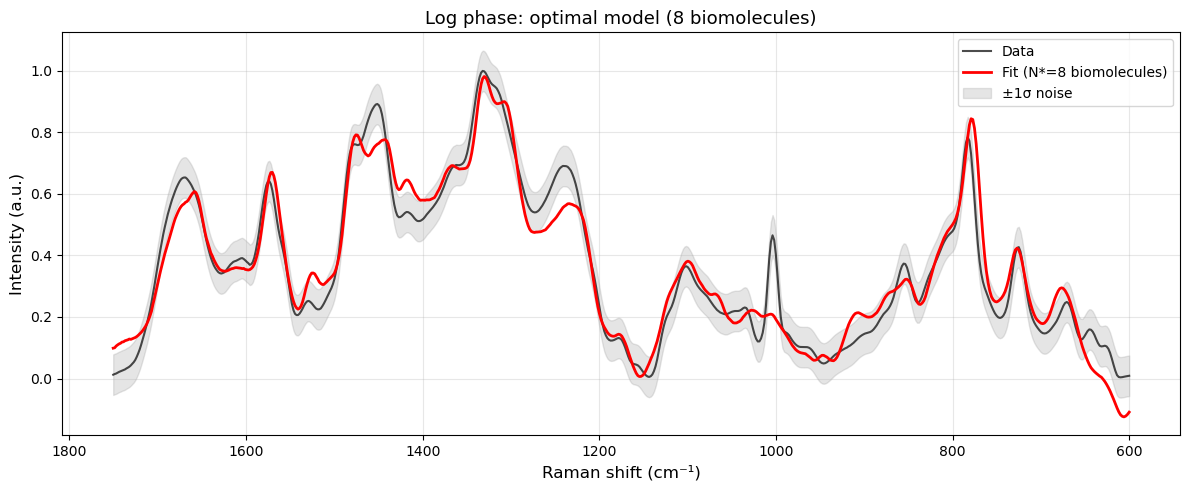

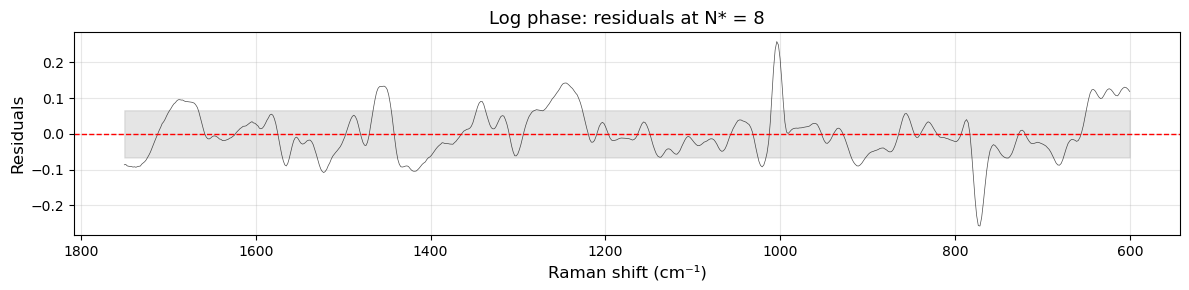

In [28]:
# Fit and residual plots for log phase at optimal model
yhat_best = history[best_idx][10]
residuals = y - yhat_best

# Top: data vs fitted spectrum
plt.figure(figsize=(12, 5))
plt.plot(x, y, 'k-', linewidth=1.5, label='Data', alpha=0.7)
plt.plot(x, yhat_best, 'r-', linewidth=2, label=f'Fit (N*={N_star} biomolecules)')
plt.fill_between(x, y - np.sqrt(s2_best), y + np.sqrt(s2_best),
                 alpha=0.2, color='gray', label=r'±1σ noise')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Intensity (a.u.)', fontsize=12)
plt.title(f'Log phase: optimal model ({N_star} biomolecules)', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Bottom: residuals — should be random and mostly within ±1σ band
plt.figure(figsize=(12, 3))
plt.plot(x, residuals, 'k-', linewidth=0.5, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.fill_between(x, -np.sqrt(s2_best), +np.sqrt(s2_best),
                 alpha=0.2, color='gray')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title(f'Log phase: residuals at N* = {N_star}', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Log Phase: Coefficient Analysis
## How much does each biomolecule contribute?

LOG PHASE: COEFFICIENTS AT N* = 8

Baseline coefficients:
  b0 = -0.0363
  b1 = 0.1339
  b2 = -0.0207

Biomolecule coefficients:
  Biomolecule     Coefficient % of total
----------------------------------------
  gsh                  0.3952      22.0%
  rna                  0.2573      14.3%
  glu                  0.2829      15.7%
  protein              0.3867      21.5%
  dna                  0.1535       8.5%
  gln                  0.1839      10.2%
  utp                  0.0909       5.1%
  glucose              0.0461       2.6%

  Total: 1.7966


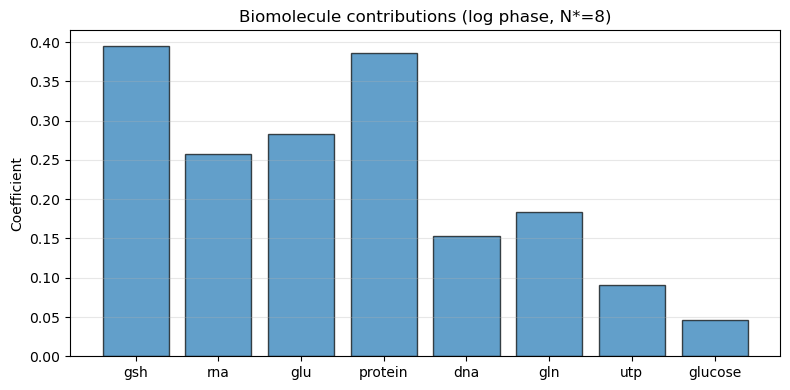

In [ ]:
# Extract fitted coefficients at optimal model
beta_best = history[best_idx][11]
baseline_coeffs = beta_best[:n_base]
coeffs_best = beta_best[n_base:]

print("=" * 60)
print(f"LOG PHASE: COEFFICIENTS AT N* = {N_star}")
print("=" * 60)

print(f"\nBaseline coefficients:")
for i, b in enumerate(baseline_coeffs):
    print(f"  b{i} = {b:.4f}")

print(f"\nBiomolecule coefficients:")
print(f"  {'Biomolecule':<14s} {'Coefficient':>12s} {'% of total':>10s}")
print("-" * 40)
total = coeffs_best.sum()
for name, c in zip(selected_names, coeffs_best):
    print(f"  {name:<14s} {c:>12.4f} {c/total*100:>9.1f}%")

print(f"\n  Total: {total:.4f}")

plt.figure(figsize=(8, 4))
plt.bar(selected_names, coeffs_best, edgecolor='black', alpha=0.7)
plt.ylabel('Coefficient')
plt.title(f'Biomolecule contributions (log phase, N*={N_star})')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Stationary Data Fitting

STATIONARY PHASE: BFI forward selection
Data points: 637
Priors: baseline Δb = 1.0, biomolecule ΔA = 1.0

step  biomolecule      k  rank  cond(X)        RSS         s²        lnBFI       ΔlnBFI
------------------------------------------------------------------------------------------
   0      (baseline)   3     3   3.76e+00   2.312e+01  3.647e-02    142.1774         -
   1             rna   4     4   5.92e+00   1.323e+01  2.090e-02    316.5093   174.3319
   2             gsh   5     5   7.57e+00   8.640e+00  1.367e-02    448.6407   132.1314
   3             glu   6     6   7.76e+00   6.293e+00  9.973e-03    546.0423    97.4016
   4             utp   7     7   8.70e+00   5.615e+00  8.912e-03    579.0607    33.0184
   5             gln   8     8   9.55e+00   5.055e+00  8.036e-03    609.2969    30.2362
   6             dna   9     9   1.14e+01   4.710e+00  7.500e-03    628.8575    19.5606
   7         glucose  10    10   1.15e+01   4.468e+00  7.126e-03    642.3793    13.5218
   8        

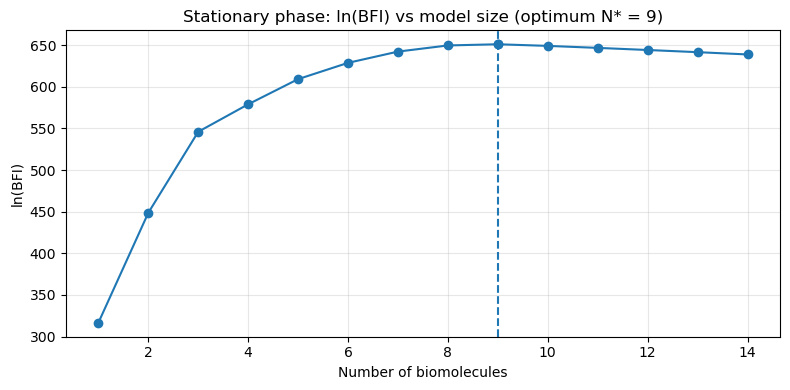

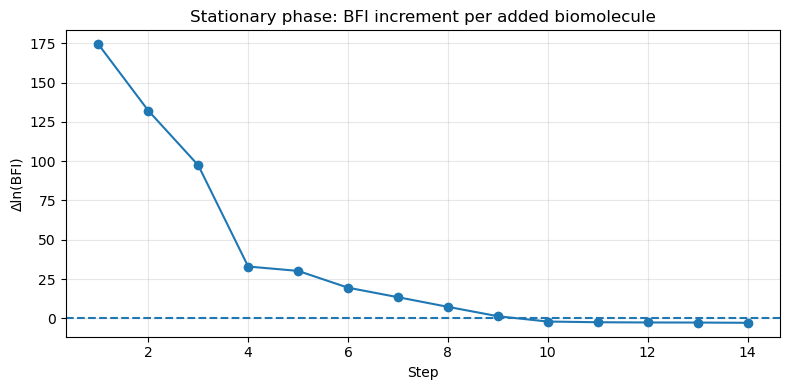

In [32]:
# ===========================
# STATIONARY PHASE: Same procedure as log phase
# ===========================
y_sta = sta_df["intensity_norm"].values

selected_sta = []
history_sta  = []

# Step 0: baseline-only model
X0 = build_design_matrix(x, R, [], baseline_deg)
beta0, yhat0, RSS0, s20, cov0, rank0, cond0 = fit_model(X0, y_sta, n_base)
prior0         = np.array([2*bmax] * n_base)
lnBFI_0        = ln_bfi(s20, cov0, prior0, n=n, k=X0.shape[1])
prev_lnBFI_sta = lnBFI_0

print("STATIONARY PHASE: BFI forward selection")
print(f"Data points: {n}")
print(f"Priors: baseline Δb = {2*bmax}, biomolecule ΔA = {Amax}")
print()
print("step  biomolecule      k  rank  cond(X)        RSS         s²        lnBFI       ΔlnBFI")
print("-" * 90)
print(f"   0  {'(baseline)':>14s}  {X0.shape[1]:>2d}  {rank0:>4d}  {cond0:>9.2e}  {RSS0:>10.3e}  {s20:>9.3e}  {lnBFI_0:>10.4f}         -")

for step in range(1, R.shape[1] + 1):
    best = None

    for idx in range(R.shape[1]):
        if idx in selected_sta:
            continue

        trial = selected_sta + [idx]
        X = build_design_matrix(x, R, trial, baseline_deg)
        beta, yhat, RSS, s2, cov, rank, cond = fit_model(X, y_sta, n_base)

        prior = np.array([2*bmax]*n_base + [Amax]*len(trial))
        lnBFI = ln_bfi(s2, cov, prior, n=n, k=X.shape[1])

        if not np.isfinite(lnBFI):
            continue

        delta = lnBFI - prev_lnBFI_sta
        if best is None or delta > best[0]:
            best = (delta, lnBFI, idx, X.shape[1], rank, cond, RSS, s2, yhat, beta)

    if best is None:
        break

    delta, lnBFI, idx, k, rank, cond, RSS, s2, yhat, beta = best
    selected_sta.append(idx)
    history_sta.append((step, idx, ref_names[idx], lnBFI, delta, k, rank, cond, RSS, s2, yhat, beta))
    print(f"{step:>4d}  {ref_names[idx]:>14s}  {k:>2d}  {rank:>4d}  {cond:>9.2e}  {RSS:>10.3e}  {s2:>9.3e}  {lnBFI:>10.4f}  {delta:>9.4f}")
    prev_lnBFI_sta = lnBFI

# ===========================
# FIND OPTIMUM MODEL + SELECTED BIOMOLECULES
# ===========================
steps_sta_arr = np.array([h[0] for h in history_sta])
lnBFI_sta_arr = np.array([h[3] for h in history_sta])
delta_sta_arr = np.array([h[4] for h in history_sta])

best_idx_sta = int(np.nanargmax(lnBFI_sta_arr))
N_star_sta   = int(steps_sta_arr[best_idx_sta])
ln_star_sta  = float(lnBFI_sta_arr[best_idx_sta])

selected_names_sta = [history_sta[i][2] for i in range(N_star_sta)]
print(f"\nOptimal model: N* = {N_star_sta} biomolecules, lnBFI = {ln_star_sta:.4f}")
print("Selected:", selected_names_sta)

# ===========================
# PLOTS
# ===========================
plt.figure(figsize=(8, 4))
plt.plot(steps_sta_arr, lnBFI_sta_arr, marker="o")
plt.axvline(N_star_sta, linestyle="--")
plt.scatter([N_star_sta], [ln_star_sta], zorder=5)
plt.xlabel("Number of biomolecules")
plt.ylabel("ln(BFI)")
plt.title(f"Stationary phase: ln(BFI) vs model size (optimum N* = {N_star_sta})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(steps_sta_arr, delta_sta_arr, marker="o")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Step")
plt.ylabel("Δln(BFI)")
plt.title("Stationary phase: BFI increment per added biomolecule")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# ===========================
# STATIONARY PHASE: RESULTS SUMMARY
# ===========================
best_entry_sta = history_sta[best_idx_sta]
k_sta    = best_entry_sta[5]
RSS_sta  = best_entry_sta[8]
s2_sta   = best_entry_sta[9]
yhat_sta = best_entry_sta[10]
beta_sta = best_entry_sta[11]

print("=" * 70)
print("STATIONARY PHASE RESULTS SUMMARY")
print("=" * 70)
print(f"Optimal number of biomolecules: N* = {N_star_sta}")
print(f"Maximum ln(BFI): {ln_star_sta:.2f}")
print(f"Data points: n = {n}")
print(f"Total parameters: k = {k_sta} (3 baseline + {N_star_sta} biomolecules)")
print(f"RSS: {RSS_sta:.4f}")
print(f"Noise estimate: s² = {s2_sta:.6f}")

print(f"\nSelected biomolecules (in order of selection):")
for i in range(N_star_sta):
    print(f"  {i+1}. {history_sta[i][2]}")

STATIONARY PHASE RESULTS SUMMARY
Optimal number of biomolecules: N* = 9
Maximum ln(BFI): 651.19
Data points: n = 637
Total parameters: k = 12 (3 baseline + 9 biomolecules)
RSS: 4.2743
Noise estimate: s² = 0.006839

Selected biomolecules (in order of selection):
  1. rna
  2. gsh
  3. glu
  4. utp
  5. gln
  6. dna
  7. glucose
  8. protein
  9. val


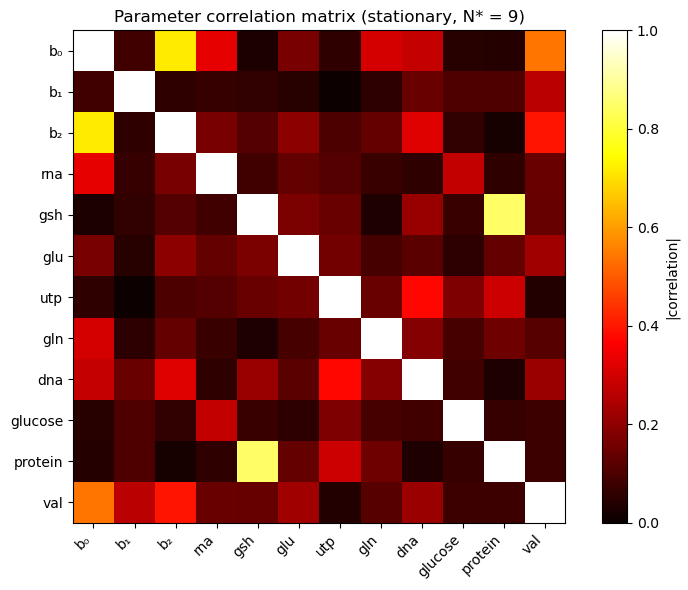

In [36]:
# Correlation matrix at optimal stationary model
X_star_sta = build_design_matrix(x, R, selected_sta[:N_star_sta], baseline_deg)
_, _, _, s2_corr_sta, cov_star_sta, _, _ = fit_model(X_star_sta, y_sta, n_base)

# Convert covariance to correlation (normalise to [-1, 1])
diag_sta = np.sqrt(np.diag(cov_star_sta))
corr_matrix_sta = cov_star_sta / np.outer(diag_sta, diag_sta)

# Parameter labels for axes
param_labels_sta = ["b₀", "b₁", "b₂"] + selected_names_sta

plt.figure(figsize=(8, 6))
plt.imshow(np.abs(corr_matrix_sta), cmap='hot', vmin=0, vmax=1)
plt.colorbar(label="|correlation|")
plt.xticks(range(len(param_labels_sta)), param_labels_sta, rotation=45, ha='right')
plt.yticks(range(len(param_labels_sta)), param_labels_sta)
plt.title(f"Parameter correlation matrix (stationary, N* = {N_star_sta})")
plt.tight_layout()
plt.show()

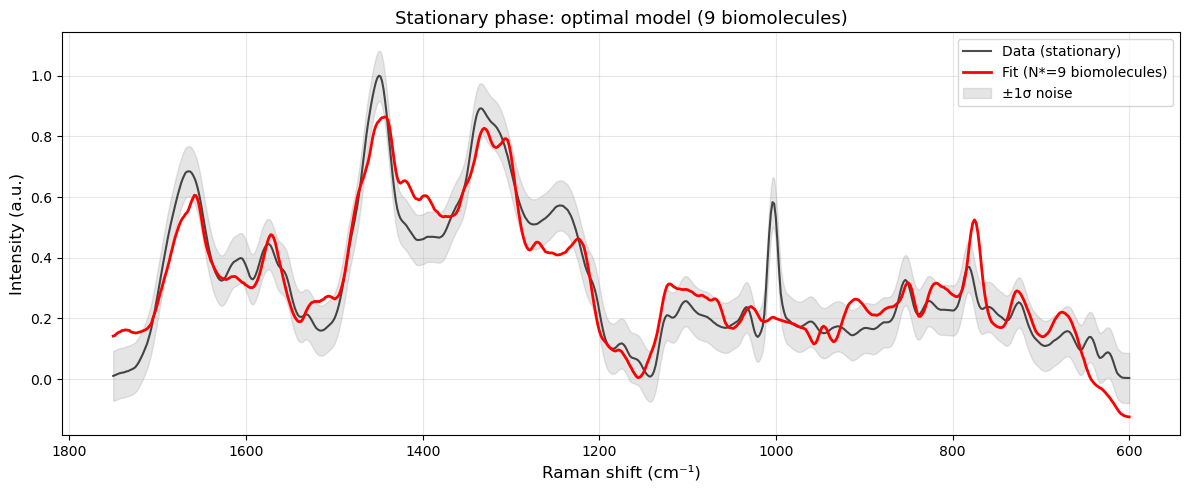

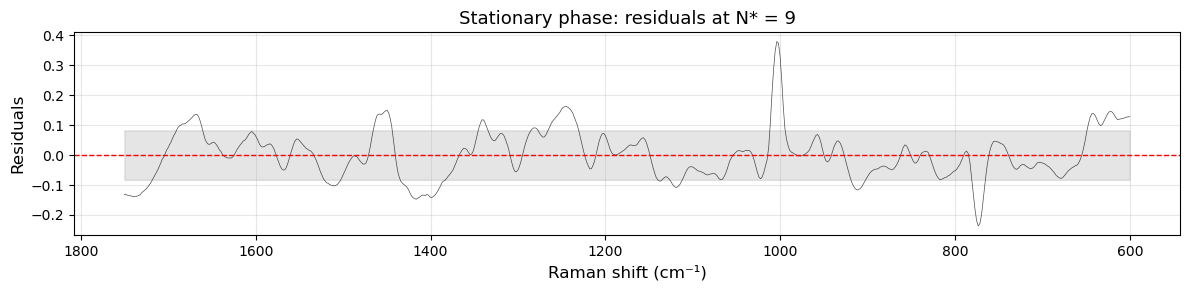

In [35]:
# Fit and residual plots for stationary phase at optimal model
residuals_sta = y_sta - yhat_sta

# Top: data vs fitted spectrum
plt.figure(figsize=(12, 5))
plt.plot(x, y_sta, 'k-', linewidth=1.5, label='Data (stationary)', alpha=0.7)
plt.plot(x, yhat_sta, 'r-', linewidth=2, label=f'Fit (N*={N_star_sta} biomolecules)')
plt.fill_between(x, y_sta - np.sqrt(s2_sta), y_sta + np.sqrt(s2_sta),
                 alpha=0.2, color='gray', label=r'±1σ noise')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Intensity (a.u.)', fontsize=12)
plt.title(f'Stationary phase: optimal model ({N_star_sta} biomolecules)', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Bottom: residuals — should be random and mostly within ±1σ band
plt.figure(figsize=(12, 3))
plt.plot(x, residuals_sta, 'k-', linewidth=0.5, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.fill_between(x, -np.sqrt(s2_sta), +np.sqrt(s2_sta),
                 alpha=0.2, color='gray')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title(f'Stationary phase: residuals at N* = {N_star_sta}', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Stationary Phase: Coefficient Analysis
## How much does each biomolecule contribute?

STATIONARY PHASE COEFFICIENTS (N* = 10)

Baseline coefficients:
  b0 = 0.0024
  b1 = 0.0728
  b2 = -0.0104

Biomolecule coefficients:
  Biomolecule     Coefficient % of total
----------------------------------------
  protein              0.6735      44.4%
  rna                  0.1867      12.3%
  gsh                  0.1596      10.5%
  atp                  0.1132       7.5%
  dna                  0.1113       7.3%
  gtp                  0.0625       4.1%
  fru-bp-1,4           0.0653       4.3%
  utp                  0.0599       4.0%
  asp                  0.0539       3.6%
  val                  0.0299       2.0%

  Total: 1.5159


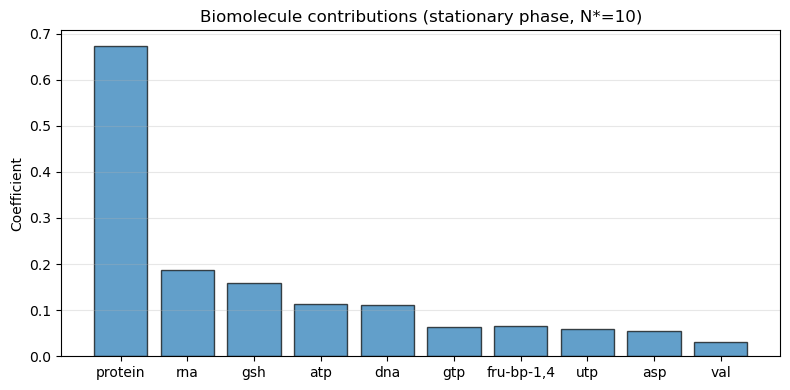

In [ ]:
# Extract fitted coefficients at optimal model
baseline_coeffs_sta = beta_sta[:n_base]
coeffs_sta = beta_sta[n_base:]

print("=" * 60)
print(f"STATIONARY PHASE: COEFFICIENTS AT N* = {N_star_sta}")
print("=" * 60)

print(f"\nBaseline coefficients:")
for i, b in enumerate(baseline_coeffs_sta):
    print(f"  b{i} = {b:.4f}")

print(f"\nBiomolecule coefficients:")
print(f"  {'Biomolecule':<14s} {'Coefficient':>12s} {'% of total':>10s}")
print("-" * 40)
total_sta = coeffs_sta.sum()
for name, c in zip(selected_names_sta, coeffs_sta):
    print(f"  {name:<14s} {c:>12.4f} {c/total_sta*100:>9.1f}%")

print(f"\n  Total: {total_sta:.4f}")

plt.figure(figsize=(8, 4))
plt.bar(selected_names_sta, coeffs_sta, edgecolor='black', alpha=0.7)
plt.ylabel('Coefficient')
plt.title(f'Biomolecule contributions (stationary phase, N*={N_star_sta})')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Comparison of Log and Stationary Phase data

COMPARISON: LOG vs STATIONARY PHASE (independent models)

  Biomolecule         Log      Sta  In Log?  In Sta?
--------------------------------------------------
  gsh              0.3952   0.0987      yes      yes
  rna              0.2573   0.3712      yes      yes
  glu              0.2829   0.3935      yes      yes
  protein          0.3867   0.1912      yes      yes
  dna              0.1535   0.1975      yes      yes
  gln              0.1839   0.2211      yes      yes
  utp              0.0909   0.1113      yes      yes
  glucose          0.0461   0.1171      yes      yes
  val              0.0000   0.0695       no      yes


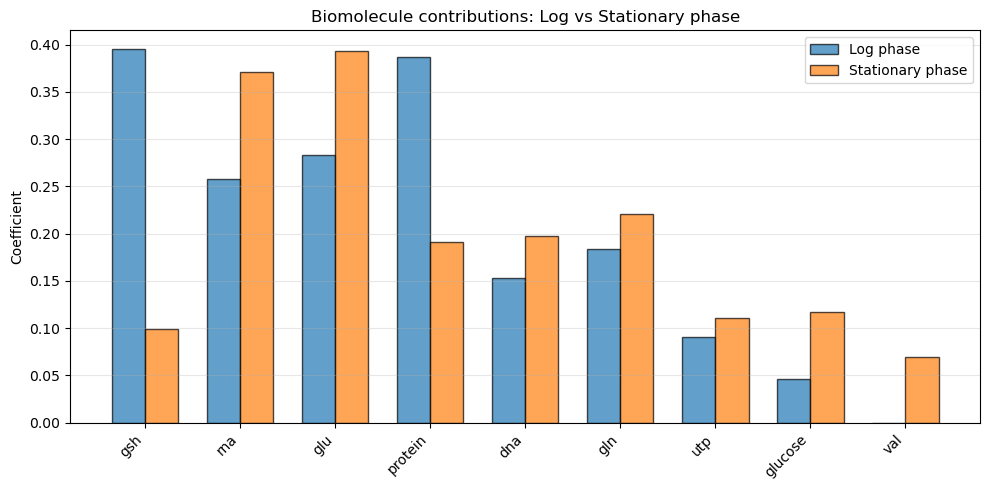

In [37]:
# ===========================
# COMPARISON: LOG vs STATIONARY PHASE
# ===========================

# Union of selected biomolecules from both phases (preserves order, removes duplicates)
all_selected = list(dict.fromkeys(selected_names + selected_names_sta))

# Get coefficients from each phase's own optimal model
beta_log     = history[best_idx][11]
beta_sta_own = history_sta[best_idx_sta][11]

log_idx = [h[1] for h in history[:N_star]]
sta_idx = [h[1] for h in history_sta[:N_star_sta]]

print("=" * 65)
print("COMPARISON: LOG vs STATIONARY PHASE (independent models)")
print("=" * 65)
print(f"\n  {'Biomolecule':<14s} {'Log':>8s} {'Sta':>8s} {'In Log?':>8s} {'In Sta?':>8s}")
print("-" * 50)

# Collect coefficients for bar chart
c_log_all = []
c_sta_all = []

for name in all_selected:
    idx = ref_names.index(name)

    if idx in log_idx:
        c_log = beta_log[n_base + log_idx.index(idx)]
    else:
        c_log = 0.0

    if idx in sta_idx:
        c_sta = beta_sta_own[n_base + sta_idx.index(idx)]
    else:
        c_sta = 0.0

    in_log = "yes" if idx in log_idx else "no"
    in_sta = "yes" if idx in sta_idx else "no"
    print(f"  {name:<14s} {c_log:>8.4f} {c_sta:>8.4f} {in_log:>8s} {in_sta:>8s}")

    c_log_all.append(c_log)
    c_sta_all.append(c_sta)

# Side-by-side bar chart
x_pos = np.arange(len(all_selected))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x_pos - width/2, c_log_all, width, label='Log phase', edgecolor='black', alpha=0.7)
plt.bar(x_pos + width/2, c_sta_all, width, label='Stationary phase', edgecolor='black', alpha=0.7)
plt.xticks(x_pos, all_selected, rotation=45, ha='right')
plt.ylabel('Coefficient')
plt.title('Biomolecule contributions: Log vs Stationary phase')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()